# Facebook Page Content Performance Analysis

Exploratory analysis of a synthetic Meta-style Facebook content export for **LumaCraft Studio**. The notebook profiles the raw export, validates data quality, engineers performance metrics, and explores how post type, timing, and hashtags relate to reach and engagement.

## 1. Load the Dataset

In [1]:
import pandas as pd

# Load the synthetic Meta-style Facebook export
file_path = "../data/LumaCraft_Studio_Facebook_Content_2025_SYNTHETIC.csv"

df = pd.read_csv(file_path)

## 2. Initial Data Exploration

A first look at the dataset's shape, columns, data types, missing values, duplicates, and summary statistics.

In [2]:
print("DATASET SHAPE")
print(df.shape)


DATASET SHAPE
(600, 31)


In [3]:
print("\nCOLUMN NAMES")
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")


COLUMN NAMES
1. Post ID
2. Page ID
3. Page name
4. Title
5. Description
6. Duration (sec)
7. Publish time
8. Caption type
9. Permalink
10. Is crosspost
11. Is share
12. Post type
13. Languages
14. Custom labels
15. Funded content status
16. Data comment
17. Date
18. Views
19. Reach
20. Reactions, comments and shares
21. Reactions
22. Comments
23. Shares
24. Total clicks
25. Matched audience targeting consumption (Photo Click)
26. Other clicks
27. Seconds viewed
28. Average Seconds viewed
29. Estimated earnings (USD)
30. Ad CPM (USD)
31. Ad impressions


In [4]:
print("\nDATA TYPES")
print(df.dtypes)


DATA TYPES
Post ID                                                   int64
Page ID                                                   int64
Page name                                                   str
Title                                                       str
Description                                                 str
Duration (sec)                                            int64
Publish time                                                str
Caption type                                                str
Permalink                                                   str
Is crosspost                                              int64
Is share                                                  int64
Post type                                                   str
Languages                                                   str
Custom labels                                           float64
Funded content status                                   float64
Data comment                

In [5]:
print("\nMISSING VALUES")
missing = df.isnull().sum()
print(missing[missing > 0])

if missing.sum() == 0:
    print("No missing values found.")


MISSING VALUES
Custom labels                                           600
Funded content status                                   600
Data comment                                            600
Matched audience targeting consumption (Photo Click)    190
Seconds viewed                                          410
Average Seconds viewed                                  410
Estimated earnings (USD)                                567
Ad CPM (USD)                                            567
Ad impressions                                          567
dtype: int64


In [6]:
print("\nDUPLICATE ROWS")
print("Number of duplicate rows:", df.duplicated().sum())


DUPLICATE ROWS
Number of duplicate rows: 0


In [7]:
print("\nDATASET INFO")
df.info()


DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 31 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   Post ID                                               600 non-null    int64  
 1   Page ID                                               600 non-null    int64  
 2   Page name                                             600 non-null    str    
 3   Title                                                 600 non-null    str    
 4   Description                                           600 non-null    str    
 5   Duration (sec)                                        600 non-null    int64  
 6   Publish time                                          600 non-null    str    
 7   Caption type                                          600 non-null    str    
 8   Permalink                                             600

In [8]:
print("\nFIRST 5 ROWS")
display(df.head())


FIRST 5 ROWS


,Post ID,Page ID,Page name,Title,Description,Duration (sec),Publish time,Caption type,Permalink,Is crosspost,...,Comments,Shares,Total clicks,Matched audience targeting consumption (Photo Click),Other clicks,Seconds viewed,Average Seconds viewed,Estimated earnings (USD),Ad CPM (USD),Ad impressions
0,100098765440019,100098765432100,LumaCraft Studio,Artisan Home Decor | Now Available,Discover our pastel shirt collection. Designed...,0,02/02/2025 18:44,Original,https://www.facebook.com/lumacraft-studio-synt...,0,...,110,69,565,224.0,341,NaN,NaN,NaN,NaN,NaN
1,100098765447938,100098765432100,LumaCraft Studio,Artisan Home Decor | Now Available,Discover our handcrafted cotton kurta set. Des...,0,10/10/2025 16:08,Original,https://www.facebook.com/lumacraft-studio-synt...,0,...,16,11,48,27.0,21,NaN,NaN,NaN,NaN,NaN
2,100098765455857,100098765432100,LumaCraft Studio,Everyday Cotton Saree | Weekend Pick,Discover our embroidered festive set. Designed...,39,08/27/2025 16:58,Original,https://www.facebook.com/lumacraft-studio-synt...,0,...,11,10,58,NaN,58,165268.0,27.6,NaN,NaN,NaN
3,100098765463776,100098765432100,LumaCraft Studio,Everyday Cotton Saree | Limited Edit,Discover our handwoven stole. Designed for eve...,30,06/10/2025 15:51,Original,https://www.facebook.com/lumacraft-studio-synt...,0,...,58,53,346,NaN,346,881784.0,14.8,31.29,4.01,7802.0
4,100098765471695,100098765432100,LumaCraft Studio,Handwoven Stole | Limited Edit,Discover our embroidered festive set. Designed...,0,06/08/2025 14:41,Original,https://www.facebook.com/lumacraft-studio-synt...,0,...,4,2,47,18.0,29,NaN,NaN,NaN,NaN,NaN


In [9]:
print("\nNUMERICAL SUMMARY")
display(df.describe().T)


NUMERICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max
Post ID,600.0,1.000988e+14,1.372754e+06,1.000988e+14,1.000988e+14,1.000988e+14,1.000988e+14,1.000988e+14
Page ID,600.0,1.000988e+14,0.000000e+00,1.000988e+14,1.000988e+14,1.000988e+14,1.000988e+14,1.000988e+14
Duration (sec),600.0,1.204333e+01,1.936664e+01,0.000000e+00,0.000000e+00,0.000000e+00,2.400000e+01,6.000000e+01
Is crosspost,600.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
Is share,600.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
Custom labels,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Funded content status,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Data comment,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Views,600.0,1.521965e+04,1.225583e+04,1.753000e+03,6.874250e+03,1.173650e+04,1.983325e+04,9.529300e+04
Reach,600.0,1.114603e+04,7.917098e+03,1.234000e+03,5.595000e+03,9.127500e+03,1.437350e+04,6.168400e+04


## 3. Data Quality Checks

Inspecting categorical fields and the raw date/time columns, and checking how missing values are distributed across post types.

In [10]:
# Check the unique values and their frequencies
# for important categorical columns

categorical_columns = [
    "Post type",
    "Caption type",
    "Languages",
    "Is crosspost",
    "Is share"
]

for column in categorical_columns:
    print(f"\n{'=' * 50}")
    print(f"{column}")
    print(f"{'=' * 50}")
    print(df[column].value_counts(dropna=False))


Post type
Post type
Photos    410
Videos    190
Name: count, dtype: int64

Caption type
Caption type
Original    555
Shared       45
Name: count, dtype: int64

Languages
Languages
English    600
Name: count, dtype: int64

Is crosspost
Is crosspost
0    600
Name: count, dtype: int64

Is share
Is share
0    600
Name: count, dtype: int64


In [11]:
# Inspect the raw date/time fields

print("PUBLISH TIME")
print("Missing:", df["Publish time"].isna().sum())

parsed_publish_time = pd.to_datetime(
    df["Publish time"],
    errors="coerce"
)

print("Unparseable:", parsed_publish_time.isna().sum())
print("Earliest:", parsed_publish_time.min())
print("Latest:", parsed_publish_time.max())

print("\nDATE COLUMN")
print("Missing:", df["Date"].isna().sum())

parsed_date = pd.to_datetime(
    df["Date"],
    errors="coerce"
)

print("Unparseable:", parsed_date.isna().sum())
print("Earliest:", parsed_date.min())
print("Latest:", parsed_date.max())

print("\nSAMPLE VALUES")
display(df[["Publish time", "Date"]].head(10))

PUBLISH TIME
Missing: 0
Unparseable: 0
Earliest: 2025-01-02 18:27:00
Latest: 2025-12-31 15:27:00

DATE COLUMN
Missing: 0
Unparseable: 600
Earliest: NaT
Latest: NaT

SAMPLE VALUES


,Publish time,Date
0,02/02/2025 18:44,Lifetime
1,10/10/2025 16:08,Lifetime
2,08/27/2025 16:58,Lifetime
3,06/10/2025 15:51,Lifetime
4,06/08/2025 14:41,Lifetime
5,11/10/2025 13:38,Lifetime
6,02/01/2025 11:26,Lifetime
7,09/12/2025 15:28,Lifetime
8,03/15/2025 12:20,Lifetime
9,02/04/2025 14:22,Lifetime


In [12]:
# Check missing values by post type

metrics_to_check = [
    "Views",
    "Reach",
    "Reactions",
    "Comments",
    "Shares",
    "Total clicks",
    "Matched audience targeting consumption (Photo Click)",
    "Seconds viewed",
    "Average Seconds viewed",
    "Estimated earnings (USD)",
    "Ad CPM (USD)",
    "Ad impressions"
]

missing_by_type = (
    df.groupby("Post type")[metrics_to_check]
      .apply(lambda x: x.isna().sum())
)

print("MISSING VALUES BY POST TYPE")
display(missing_by_type)

MISSING VALUES BY POST TYPE


,Views,Reach,Reactions,Comments,Shares,Total clicks,Matched audience targeting consumption (Photo Click),Seconds viewed,Average Seconds viewed,Estimated earnings (USD),Ad CPM (USD),Ad impressions
Post type,,,,,,,,,,,,
Photos,0,0,0,0,0,0,0,410,410,410,410,410
Videos,0,0,0,0,0,0,190,0,0,157,157,157


## 4. Feature Engineering: Datetime Fields

Parsing `Publish time` into a proper datetime and deriving `Date`, `Month`, `Day of Week`, and `Hour` fields for later time-based analysis.

In [13]:
# Convert Publish time into datetime
df["Publish time"] = pd.to_datetime(df["Publish time"])

# Create useful time-based features
df["Date"] = df["Publish time"].dt.date
df["Month"] = df["Publish time"].dt.month
df["Day of Week"] = df["Publish time"].dt.day_name()
df["Hour"] = df["Publish time"].dt.hour

# Check the result
display(df[["Publish time", "Date", "Month", "Day of Week", "Hour"]].head())

print("\nDATETIME RANGE:")
print("Start:", df["Publish time"].min())
print("End:", df["Publish time"].max())

,Publish time,Date,Month,Day of Week,Hour
0,2025-02-02 18:44:00,2025-02-02,2,Sunday,18
1,2025-10-10 16:08:00,2025-10-10,10,Friday,16
2,2025-08-27 16:58:00,2025-08-27,8,Wednesday,16
3,2025-06-10 15:51:00,2025-06-10,6,Tuesday,15
4,2025-06-08 14:41:00,2025-06-08,6,Sunday,14



DATETIME RANGE:
Start: 2025-01-02 18:27:00
End: 2025-12-31 15:27:00


## 5. Consistency & Validation Checks

Sanity-checking the metrics: confirming engagement totals add up, looking for logically inconsistent rows (e.g. Reach > Views), and verifying that `Post ID` is a unique identifier.

In [14]:
# Check whether total engagement equals reactions + comments + shares

df["Calculated Engagement"] = (
    df["Reactions"] +
    df["Comments"] +
    df["Shares"]
)

df["Engagement Difference"] = (
    df["Reactions, comments and shares"] -
    df["Calculated Engagement"]
)

print("ENGAGEMENT DIFFERENCE")
print(df["Engagement Difference"].value_counts().head())

print("\nRows with a mismatch:",
      (df["Engagement Difference"] != 0).sum())

ENGAGEMENT DIFFERENCE
Engagement Difference
0    600
Name: count, dtype: int64

Rows with a mismatch: 0


In [15]:
# Check basic metric consistency

print("Posts where Reach > Views:",
      (df["Reach"] > df["Views"]).sum())

print("Posts where Reactions > Reach:",
      (df["Reactions"] > df["Reach"]).sum())

print("Posts where Comments > Reach:",
      (df["Comments"] > df["Reach"]).sum())

print("Posts where Shares > Reach:",
      (df["Shares"] > df["Reach"]).sum())

Posts where Reach > Views: 78
Posts where Reactions > Reach: 0
Posts where Comments > Reach: 0
Posts where Shares > Reach: 0


In [16]:
# Inspect posts where Reach is greater than Views

reach_gt_views = df[df["Reach"] > df["Views"]]

display(
    reach_gt_views[
        [
            "Post ID",
            "Post type",
            "Views",
            "Reach",
            "Reactions",
            "Comments",
            "Shares"
        ]
    ].head(20)
)

print("Total affected rows:", len(reach_gt_views))

,Post ID,Post type,Views,Reach,Reactions,Comments,Shares
39,100098765748860,Photos,5132,5736,258,21,16
52,100098765851807,Photos,13126,13592,456,25,23
73,100098766018106,Photos,6471,7181,381,23,14
83,100098766097296,Photos,18422,19222,898,27,34
89,100098766144810,Photos,2618,2785,55,5,2
124,100098766421975,Photos,16629,17349,654,38,24
136,100098766517003,Photos,8330,8447,321,21,15
142,100098766564517,Photos,5323,5788,316,10,14
145,100098766588274,Photos,3244,3683,84,6,3
149,100098766619950,Photos,3809,3982,131,9,7


Total affected rows: 78


In [17]:
# Check whether Post ID is unique

duplicate_post_ids = df["Post ID"].duplicated().sum()

print("Duplicate Post IDs:", duplicate_post_ids)
print("Unique Post IDs:", df["Post ID"].nunique())
print("Total rows:", len(df))

Duplicate Post IDs: 0
Unique Post IDs: 600
Total rows: 600


## 6. Publishing Volume & Core Performance Metrics

Counting posts published per month and creating the core performance metrics used throughout the rest of the analysis: `Engagement Rate (%)` and `Click Rate (%)`.

In [18]:
# Check number of posts published each month

monthly_posts = (
    df.groupby("Month")
      .size()
      .reset_index(name="Post Count")
)

display(monthly_posts)

,Month,Post Count
0,1,43
1,2,61
2,3,46
3,4,54
4,5,37
5,6,59
6,7,51
7,8,45
8,9,46
9,10,63


In [19]:
# Create core performance metrics

df["Engagement Rate (%)"] = (
    df["Reactions, comments and shares"] / df["Reach"] * 100
)

df["Click Rate (%)"] = (
    df["Total clicks"] / df["Reach"] * 100
)

# Check the new metrics
display(
    df[
        [
            "Post ID",
            "Reach",
            "Reactions, comments and shares",
            "Total clicks",
            "Engagement Rate (%)",
            "Click Rate (%)"
        ]
    ].head(10)
)

,Post ID,Reach,"Reactions, comments and shares",Total clicks,Engagement Rate (%),Click Rate (%)
0,100098765440019,47583,1172,565,2.463065,1.187399
1,100098765447938,4564,248,48,5.433830,1.051709
2,100098765455857,4586,173,58,3.772351,1.264719
3,100098765463776,28815,1176,346,4.081208,1.200763
4,100098765471695,3306,106,47,3.206292,1.421658
5,100098765479614,8589,293,106,3.411340,1.234137
6,100098765487533,12483,502,162,4.021469,1.297765
7,100098765495452,3356,90,33,2.681764,0.983313
8,100098765503371,5998,117,82,1.950650,1.367122
9,100098765511290,5492,217,61,3.951202,1.110706


In [20]:
# Check the distribution of the new performance metrics

print("ENGAGEMENT RATE (%)")
print(df["Engagement Rate (%)"].describe())

print("\nCLICK RATE (%)")
print(df["Click Rate (%)"].describe())

ENGAGEMENT RATE (%)
count    600.000000
mean       3.656482
std        1.301088
min        0.229944
25%        2.806050
50%        3.677274
75%        4.575681
max        7.239459
Name: Engagement Rate (%), dtype: float64

CLICK RATE (%)
count    600.000000
mean       1.198501
std        0.130470
min        0.746269
25%        1.119236
50%        1.197123
75%        1.277445
max        1.688555
Name: Click Rate (%), dtype: float64


## 7. Performance by Post Type

Comparing Photos vs. Videos (and other post types) on reach, views, engagement rate, and click rate, using both mean and median summaries with supporting charts.

In [21]:
# Compare performance of Photos vs Videos

post_type_performance = (
    df.groupby("Post type")
      .agg(
          Post_Count=("Post ID", "count"),
          Avg_Reach=("Reach", "mean"),
          Avg_Views=("Views", "mean"),
          Avg_Engagement_Rate=("Engagement Rate (%)", "mean"),
          Avg_Click_Rate=("Click Rate (%)", "mean")
      )
      .round(2)
      .reset_index()
)

display(post_type_performance)

,Post type,Post_Count,Avg_Reach,Avg_Views,Avg_Engagement_Rate,Avg_Click_Rate
0,Photos,410,10011.27,11958.13,3.91,1.2
1,Videos,190,13594.73,22257.67,3.11,1.2


In [22]:
# Compare median performance of Photos vs Videos

post_type_median = (
    df.groupby("Post type")
      .agg(
          Median_Reach=("Reach", "median"),
          Median_Views=("Views", "median"),
          Median_Engagement_Rate=("Engagement Rate (%)", "median"),
          Median_Click_Rate=("Click Rate (%)", "median")
      )
      .round(2)
      .reset_index()
)

display(post_type_median)

,Post type,Median_Reach,Median_Views,Median_Engagement_Rate,Median_Click_Rate
0,Photos,7990.0,9646.5,3.91,1.20
1,Videos,10641.0,18589.5,2.98,1.21


In [23]:
# Average reach by post type

reach_by_type = (
    df.groupby("Post type")["Reach"]
      .mean()
      .round(0)
      .reset_index()
)

display(reach_by_type)

,Post type,Reach
0,Photos,10011.0
1,Videos,13595.0


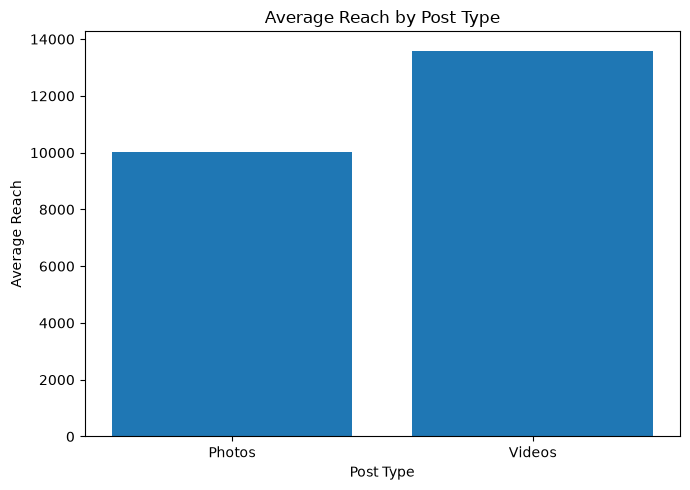

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.bar(
    reach_by_type["Post type"],
    reach_by_type["Reach"]
)

plt.title("Average Reach by Post Type")
plt.xlabel("Post Type")
plt.ylabel("Average Reach")

plt.tight_layout()
plt.show()

In [25]:
# Average views by post type

views_by_type = (
    df.groupby("Post type")["Views"]
      .mean()
      .round(0)
      .reset_index()
)

display(views_by_type)

,Post type,Views
0,Photos,11958.0
1,Videos,22258.0


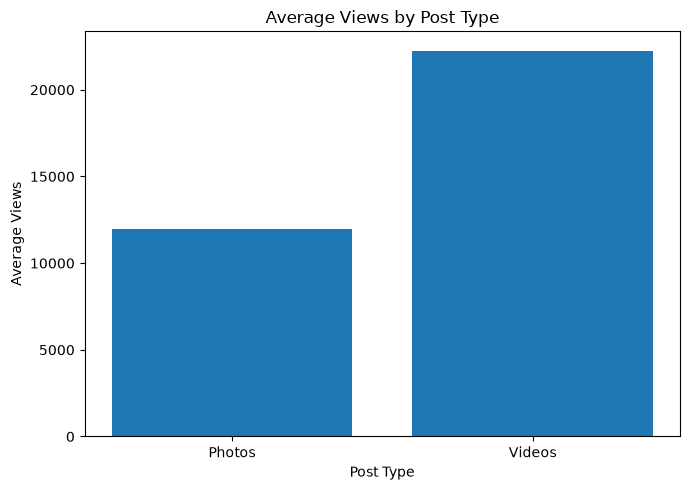

In [26]:
plt.figure(figsize=(7, 5))

plt.bar(
    views_by_type["Post type"],
    views_by_type["Views"]
)

plt.title("Average Views by Post Type")
plt.xlabel("Post Type")
plt.ylabel("Average Views")

plt.tight_layout()
plt.show()

In [27]:
# Average engagement rate by post type

engagement_by_type = (
    df.groupby("Post type")["Engagement Rate (%)"]
      .mean()
      .round(2)
      .reset_index()
)

display(engagement_by_type)

,Post type,Engagement Rate (%)
0,Photos,3.91
1,Videos,3.11


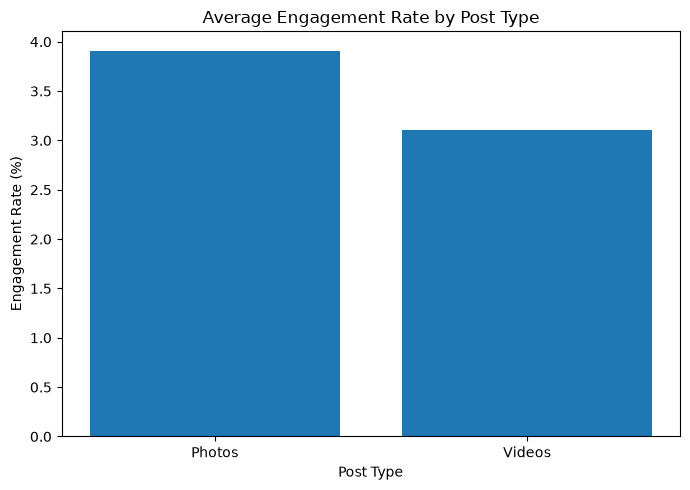

In [28]:
plt.figure(figsize=(7, 5))

plt.bar(
    engagement_by_type["Post type"],
    engagement_by_type["Engagement Rate (%)"]
)

plt.title("Average Engagement Rate by Post Type")
plt.xlabel("Post Type")
plt.ylabel("Engagement Rate (%)")

plt.tight_layout()
plt.show()

## 8. Performance Over Time

Looking at how reach and engagement rate vary by month, day of week, posting hour, and broader time-of-day periods.

In [29]:
# Calculate average reach by month

monthly_reach = (
    df.groupby("Month")["Reach"]
      .mean()
      .round(0)
      .reset_index()
)

display(monthly_reach)

,Month,Reach
0,1,11230.0
1,2,11239.0
2,3,12020.0
3,4,12262.0
4,5,11626.0
5,6,12508.0
6,7,10409.0
7,8,12002.0
8,9,9712.0
9,10,9403.0


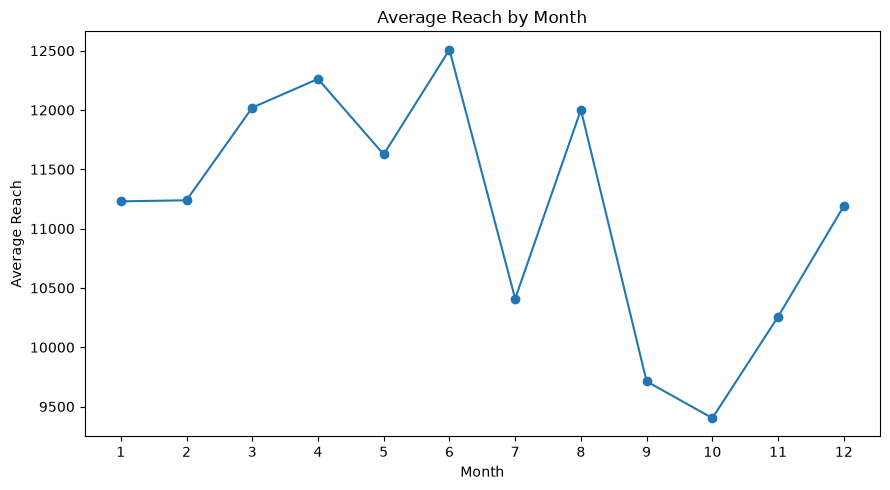

In [30]:
plt.figure(figsize=(9, 5))

plt.plot(
    monthly_reach["Month"],
    monthly_reach["Reach"],
    marker="o"
)

plt.title("Average Reach by Month")
plt.xlabel("Month")
plt.ylabel("Average Reach")
plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

In [31]:
# Calculate average engagement rate by month

monthly_engagement = (
    df.groupby("Month")["Engagement Rate (%)"]
      .mean()
      .round(2)
      .reset_index()
)

display(monthly_engagement)

,Month,Engagement Rate (%)
0,1,3.60
1,2,3.77
2,3,3.27
3,4,3.49
4,5,3.77
5,6,3.70
6,7,3.83
7,8,3.64
8,9,3.71
9,10,3.67


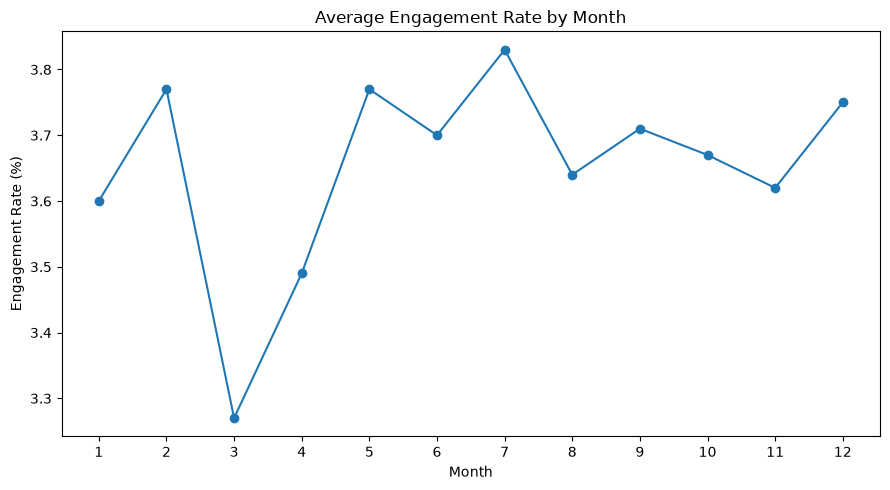

In [32]:
plt.figure(figsize=(9, 5))

plt.plot(
    monthly_engagement["Month"],
    monthly_engagement["Engagement Rate (%)"],
    marker="o"
)

plt.title("Average Engagement Rate by Month")
plt.xlabel("Month")
plt.ylabel("Engagement Rate (%)")
plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

In [33]:
# Average reach by day of week

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

daily_reach = (
    df.groupby("Day of Week")["Reach"]
      .mean()
      .reindex(day_order)
      .round(0)
      .reset_index()
)

display(daily_reach)

,Day of Week,Reach
0,Monday,9901.0
1,Tuesday,10965.0
2,Wednesday,10768.0
3,Thursday,9608.0
4,Friday,10121.0
5,Saturday,12808.0
6,Sunday,13403.0


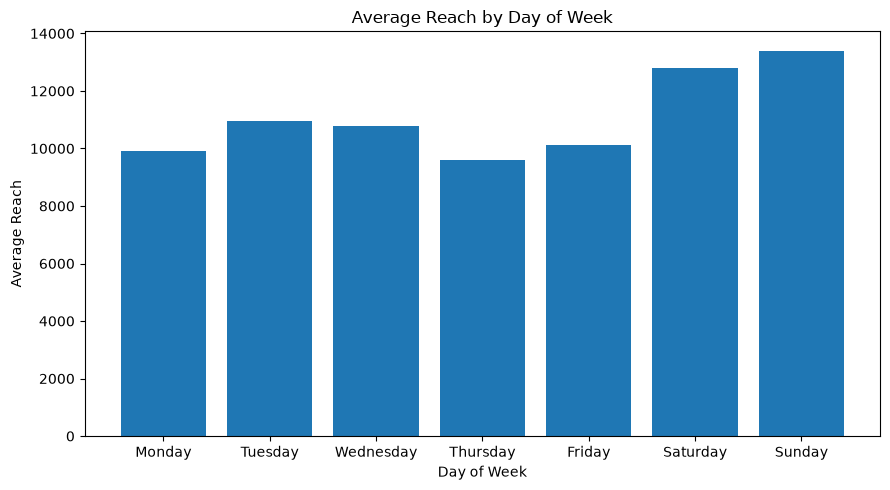

In [34]:
plt.figure(figsize=(9, 5))

plt.bar(
    daily_reach["Day of Week"],
    daily_reach["Reach"]
)

plt.title("Average Reach by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Reach")

plt.tight_layout()
plt.show()

In [35]:
# Average engagement rate by day of week

daily_engagement = (
    df.groupby("Day of Week")["Engagement Rate (%)"]
      .mean()
      .reindex(day_order)
      .round(2)
      .reset_index()
)

display(daily_engagement)

,Day of Week,Engagement Rate (%)
0,Monday,3.72
1,Tuesday,3.81
2,Wednesday,3.71
3,Thursday,3.84
4,Friday,3.55
5,Saturday,3.43
6,Sunday,3.63


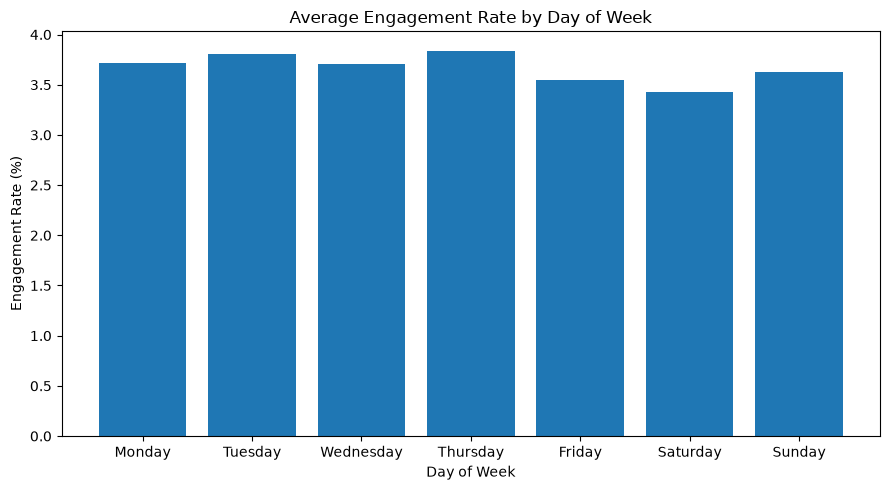

In [36]:
plt.figure(figsize=(9, 5))

plt.bar(
    daily_engagement["Day of Week"],
    daily_engagement["Engagement Rate (%)"]
)

plt.title("Average Engagement Rate by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Engagement Rate (%)")

plt.tight_layout()
plt.show()

In [37]:
# Average reach by posting hour

hourly_reach = (
    df.groupby("Hour")["Reach"]
      .mean()
      .round(0)
      .reset_index()
)

display(hourly_reach)

,Hour,Reach
0,6,6825.0
1,7,6080.0
2,8,8968.0
3,9,12458.0
4,10,8339.0
5,11,8127.0
6,12,10828.0
7,13,12789.0
8,14,11335.0
9,15,13502.0


In [38]:
# Check number of posts published at each hour

hourly_post_count = (
    df.groupby("Hour")
      .size()
      .reset_index(name="Post Count")
)

display(hourly_post_count)

,Hour,Post Count
0,6,13
1,7,9
2,8,15
3,9,10
4,10,26
5,11,37
6,12,31
7,13,44
8,14,47
9,15,61


In [39]:
# Group posting hours into broader time periods

def get_time_period(hour):
    if 6 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 18:
        return "Afternoon"
    else:
        return "Evening"


df["Time Period"] = df["Hour"].apply(get_time_period)

time_period_performance = (
    df.groupby("Time Period")
      .agg(
          Post_Count=("Post ID", "count"),
          Avg_Reach=("Reach", "mean"),
          Avg_Engagement_Rate=("Engagement Rate (%)", "mean")
      )
      .round(2)
      .reset_index()
)

display(time_period_performance)

,Time Period,Post_Count,Avg_Reach,Avg_Engagement_Rate
0,Afternoon,328,9744.17,3.66
1,Evening,162,15873.30,3.62
2,Morning,110,8364.13,3.69


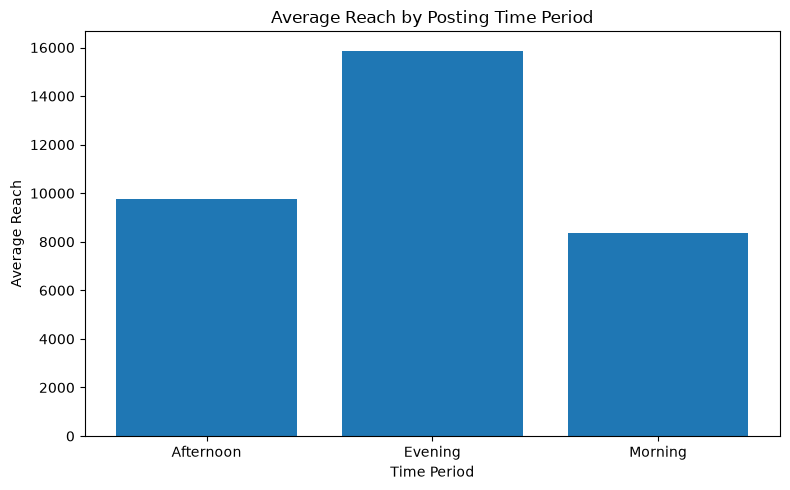

In [40]:
# Average reach by posting time period

plt.figure(figsize=(8, 5))

plt.bar(
    time_period_performance["Time Period"],
    time_period_performance["Avg_Reach"]
)

plt.title("Average Reach by Posting Time Period")
plt.xlabel("Time Period")
plt.ylabel("Average Reach")

plt.tight_layout()
plt.show()

In [41]:
# Compare reach across post type and posting time period

type_time_reach = (
    df.groupby(["Time Period", "Post type"])["Reach"]
      .mean()
      .round(0)
      .reset_index()
)

display(type_time_reach)

,Time Period,Post type,Reach
0,Afternoon,Photos,8811.0
1,Afternoon,Videos,11726.0
2,Evening,Photos,14352.0
3,Evening,Videos,19091.0
4,Morning,Photos,7287.0
5,Morning,Videos,10879.0


In [42]:
# Check number of posts in each post type and time period

type_time_count = (
    df.groupby(["Time Period", "Post type"])
      .size()
      .reset_index(name="Post Count")
)

display(type_time_count)

,Time Period,Post type,Post Count
0,Afternoon,Photos,223
1,Afternoon,Videos,105
2,Evening,Photos,110
3,Evening,Videos,52
4,Morning,Photos,77
5,Morning,Videos,33


## 9. Engagement Composition

Breaking down engagement into its components — reactions, comments, and shares — overall and by post type.

In [43]:
# Compare engagement components by post type

engagement_components = (
    df.groupby("Post type")
      .agg(
          Avg_Reactions=("Reactions", "mean"),
          Avg_Comments=("Comments", "mean"),
          Avg_Shares=("Shares", "mean")
      )
      .round(2)
      .reset_index()
)

display(engagement_components)

,Post type,Avg_Reactions,Avg_Comments,Avg_Shares
0,Photos,348.46,21.85,17.83
1,Videos,375.85,29.59,24.26


In [44]:
# Overall engagement composition

engagement_totals = {
    "Reactions": df["Reactions"].sum(),
    "Comments": df["Comments"].sum(),
    "Shares": df["Shares"].sum()
}

engagement_composition = (
    pd.Series(engagement_totals)
      .to_frame("Total")
)

engagement_composition["Percentage"] = (
    engagement_composition["Total"] /
    engagement_composition["Total"].sum() * 100
).round(2)

display(engagement_composition)

,Total,Percentage
Reactions,214282,88.99
Comments,14581,6.06
Shares,11922,4.95


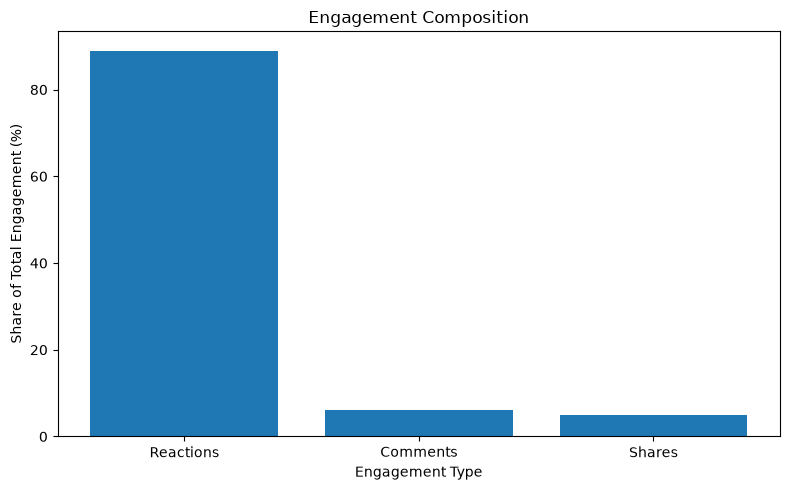

In [45]:
# Visualize engagement composition

plt.figure(figsize=(8, 5))

plt.bar(
    engagement_composition.index,
    engagement_composition["Percentage"]
)

plt.title("Engagement Composition")
plt.xlabel("Engagement Type")
plt.ylabel("Share of Total Engagement (%)")

plt.tight_layout()
plt.show()

## 10. Hashtag Analysis

Extracting hashtags from post descriptions and analyzing their frequency and associated performance.

In [46]:
# Inspect descriptions to understand hashtag format

display(
    df[["Post ID", "Description"]]
    .head(20)
)

,Post ID,Description
0,100098765440019,Discover our pastel shirt collection. Designed...
1,100098765447938,Discover our handcrafted cotton kurta set. Des...
2,100098765455857,Discover our embroidered festive set. Designed...
3,100098765463776,Discover our handwoven stole. Designed for eve...
4,100098765471695,Discover our embroidered festive set. Designed...
5,100098765479614,Discover our everyday cotton saree. Designed f...
6,100098765487533,Discover our handwoven stole. Designed for eve...
7,100098765495452,Discover our minimalist tote bag. Designed for...
8,100098765503371,Discover our minimalist tote bag. Designed for...
9,100098765511290,Discover our minimalist tote bag. Designed for...


In [47]:
# Check whether descriptions contain hashtags

hashtag_posts = df["Description"].str.contains("#", na=False).sum()

print("Posts containing hashtags:", hashtag_posts)
print("Posts without hashtags:", len(df) - hashtag_posts)

# Show a few complete descriptions containing hashtags
display(
    df.loc[
        df["Description"].str.contains("#", na=False),
        "Description"
    ].head(10).to_string(index=False)
)

Posts containing hashtags: 600
Posts without hashtags: 0


'Discover our pastel shirt collection. Designed ...\nDiscover our handcrafted cotton kurta set. Desi...\nDiscover our embroidered festive set. Designed ...\nDiscover our handwoven stole. Designed for ever...\nDiscover our embroidered festive set. Designed ...\nDiscover our everyday cotton saree. Designed fo...\nDiscover our handwoven stole. Designed for ever...\nDiscover our minimalist tote bag. Designed for ...\nDiscover our minimalist tote bag. Designed for ...\nDiscover our minimalist tote bag. Designed for ...'

In [48]:
# Extract hashtags from each post description

df["Hashtags"] = df["Description"].str.findall(r"#\w+")

# Count how many hashtags each post contains
df["Hashtag Count"] = df["Hashtags"].str.len()

print("Average hashtags per post:",
      round(df["Hashtag Count"].mean(), 2))

print("Minimum hashtags in a post:",
      df["Hashtag Count"].min())

print("Maximum hashtags in a post:",
      df["Hashtag Count"].max())

# Show examples
display(
    df[["Post ID", "Hashtags", "Hashtag Count"]].head(10)
)

Average hashtags per post: 2.0
Minimum hashtags in a post: 2
Maximum hashtags in a post: 2


,Post ID,Hashtags,Hashtag Count
0,100098765440019,"[#NewDrop, #CottonLove]",2
1,100098765447938,"[#NewDrop, #EverydayStyle]",2
2,100098765455857,"[#NewDrop, #StyleInspiration]",2
3,100098765463776,"[#FestiveEdit, #CottonLove]",2
4,100098765471695,"[#LumaCraft, #StyleInspiration]",2
5,100098765479614,"[#CottonLove, #Handmade]",2
6,100098765487533,"[#NewDrop, #NewDrop]",2
7,100098765495452,"[#EverydayStyle, #Handmade]",2
8,100098765503371,"[#NewDrop, #StyleInspiration]",2
9,100098765511290,"[#Handmade, #Handmade]",2


In [49]:
# Count unique hashtag usage across posts

from collections import Counter

hashtag_counts = Counter()

for hashtags in df["Hashtags"]:
    hashtag_counts.update(set(hashtags))

hashtag_frequency = (
    pd.DataFrame(
        hashtag_counts.items(),
        columns=["Hashtag", "Post Count"]
    )
    .sort_values("Post Count", ascending=False)
    .reset_index(drop=True)
)

display(hashtag_frequency)

,Hashtag,Post Count
0,#EverydayStyle,159
1,#NewDrop,141
2,#Handmade,141
3,#FestiveEdit,139
4,#LumaCraft,137
5,#CottonLove,134
6,#ShopSmall,130
7,#StyleInspiration,129


In [50]:
# Analyze performance associated with each hashtag

hashtag_performance = []

for hashtag in hashtag_frequency["Hashtag"]:
    hashtag_posts = df[df["Hashtags"].apply(lambda tags: hashtag in set(tags))]

    hashtag_performance.append({
        "Hashtag": hashtag,
        "Post Count": len(hashtag_posts),
        "Avg Reach": hashtag_posts["Reach"].mean(),
        "Avg Engagement Rate": hashtag_posts["Engagement Rate (%)"].mean()
    })

hashtag_performance = (
    pd.DataFrame(hashtag_performance)
      .sort_values("Avg Engagement Rate", ascending=False)
      .round(2)
      .reset_index(drop=True)
)

display(hashtag_performance)

,Hashtag,Post Count,Avg Reach,Avg Engagement Rate
0,#Handmade,141,11368.66,3.82
1,#ShopSmall,130,11074.44,3.71
2,#LumaCraft,137,11263.70,3.69
3,#CottonLove,134,11475.39,3.65
4,#NewDrop,141,11313.71,3.62
5,#StyleInspiration,129,9585.57,3.60
6,#FestiveEdit,139,12246.94,3.55
7,#EverydayStyle,159,11254.20,3.53


In [51]:
# Identify top-performing posts by engagement rate

top_posts = (
    df[
        [
            "Post ID",
            "Post type",
            "Publish time",
            "Reach",
            "Reactions, comments and shares",
            "Engagement Rate (%)",
            "Click Rate (%)",
            "Description"
        ]
    ]
    .sort_values("Engagement Rate (%)", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

display(top_posts)

,Post ID,Post type,Publish time,Reach,"Reactions, comments and shares",Engagement Rate (%),Click Rate (%),Description
0,100098769510385,Photos,2025-12-17 16:21:00,18855,1365,7.239459,1.225139,Discover our linen co-ord set. Designed for ev...
1,100098767316822,Photos,2025-06-07 19:20:00,14465,1011,6.989284,1.306602,Discover our embroidered festive set. Designed...
2,100098767293065,Photos,2025-06-29 19:36:00,23371,1632,6.983013,1.193787,Discover our printed summer dress. Designed fo...
3,100098769059002,Videos,2025-08-20 14:55:00,14375,993,6.907826,1.321739,Discover our pastel shirt collection. Designed...
4,100098767570230,Photos,2025-08-04 13:52:00,4660,311,6.673820,1.115880,Discover our embroidered festive set. Designed...
5,100098765653832,Photos,2025-10-28 20:08:00,12797,839,6.556224,1.125264,Discover our handwoven stole. Designed for eve...
6,100098766920872,Photos,2025-05-20 16:29:00,3635,236,6.492435,1.430536,Discover our pastel shirt collection. Designed...
7,100098768544267,Videos,2025-05-15 11:18:00,12920,829,6.416409,1.122291,Discover our linen co-ord set. Designed for ev...
8,100098766770411,Photos,2025-05-03 12:14:00,6137,393,6.403780,0.831025,Discover our minimalist tote bag. Designed for...
9,100098766873358,Photos,2025-02-25 15:50:00,5704,363,6.363955,0.911641,Discover our printed summer dress. Designed fo...


In [52]:
# Add extracted hashtags to the top-performing posts

top_posts_with_hashtags = (
    df[
        [
            "Post ID",
            "Post type",
            "Publish time",
            "Reach",
            "Engagement Rate (%)",
            "Hashtags"
        ]
    ]
    .sort_values("Engagement Rate (%)", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

display(top_posts_with_hashtags)

,Post ID,Post type,Publish time,Reach,Engagement Rate (%),Hashtags
0,100098769510385,Photos,2025-12-17 16:21:00,18855,7.239459,"[#EverydayStyle, #ShopSmall]"
1,100098767316822,Photos,2025-06-07 19:20:00,14465,6.989284,"[#NewDrop, #EverydayStyle]"
2,100098767293065,Photos,2025-06-29 19:36:00,23371,6.983013,"[#ShopSmall, #StyleInspiration]"
3,100098769059002,Videos,2025-08-20 14:55:00,14375,6.907826,"[#ShopSmall, #Handmade]"
4,100098767570230,Photos,2025-08-04 13:52:00,4660,6.673820,"[#LumaCraft, #ShopSmall]"
5,100098765653832,Photos,2025-10-28 20:08:00,12797,6.556224,"[#ShopSmall, #CottonLove]"
6,100098766920872,Photos,2025-05-20 16:29:00,3635,6.492435,"[#StyleInspiration, #FestiveEdit]"
7,100098768544267,Videos,2025-05-15 11:18:00,12920,6.416409,"[#LumaCraft, #FestiveEdit]"
8,100098766770411,Photos,2025-05-03 12:14:00,6137,6.403780,"[#CottonLove, #LumaCraft]"
9,100098766873358,Photos,2025-02-25 15:50:00,5704,6.363955,"[#LumaCraft, #Handmade]"


## 11. Correlation Analysis

Measuring how reach relates to engagement rate and click rate.

In [53]:
# Measure the relationship between reach and engagement rate

reach_engagement_corr = df[
    ["Reach", "Engagement Rate (%)"]
].corr()

display(reach_engagement_corr)

,Reach,Engagement Rate (%)
Reach,1.000000,-0.060719
Engagement Rate (%),-0.060719,1.000000


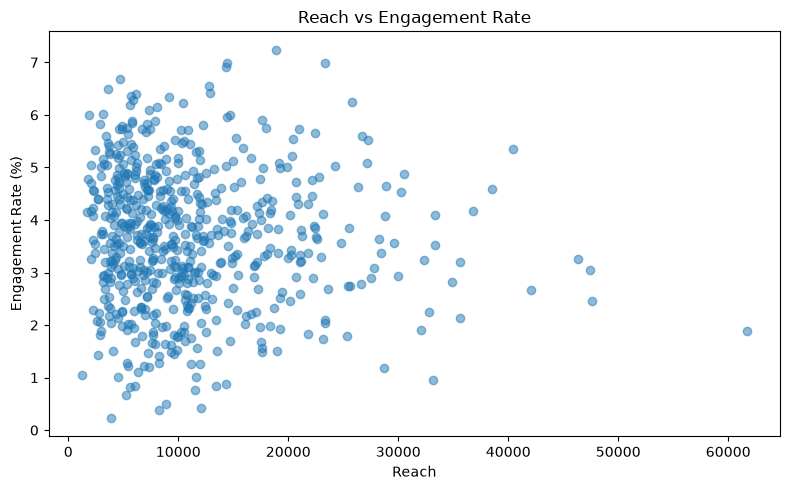

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Reach"],
    df["Engagement Rate (%)"],
    alpha=0.5
)

plt.xlabel("Reach")
plt.ylabel("Engagement Rate (%)")
plt.title("Reach vs Engagement Rate")

plt.tight_layout()
plt.show()

In [55]:
# Measure the relationship between reach and click rate

reach_click_corr = df[
    ["Reach", "Click Rate (%)"]
].corr()

display(reach_click_corr)

,Reach,Click Rate (%)
Reach,1.000000,-0.003901
Click Rate (%),-0.003901,1.000000


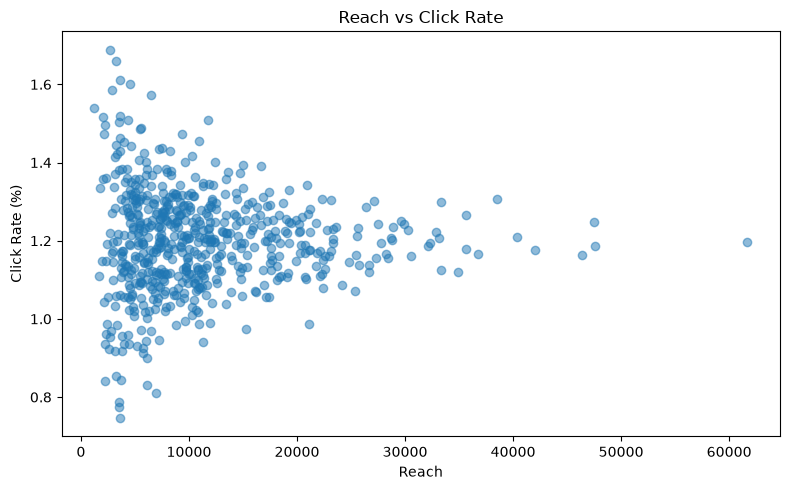

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Reach"],
    df["Click Rate (%)"],
    alpha=0.5
)

plt.xlabel("Reach")
plt.ylabel("Click Rate (%)")
plt.title("Reach vs Click Rate")

plt.tight_layout()
plt.show()

## 12. Top 10 Posts: Representation Analysis

Comparing the post types and hashtags found in the top 10 highest-engagement posts against their overall representation in the dataset.

In [57]:
top_10_posts = (
    df[
        [
            "Post ID",
            "Post type",
            "Publish time",
            "Reach",
            "Engagement Rate (%)",
            "Hashtags"
        ]
    ]
    .sort_values("Engagement Rate (%)", ascending=False)
    .head(10)
)

display(top_10_posts)

,Post ID,Post type,Publish time,Reach,Engagement Rate (%),Hashtags
514,100098769510385,Photos,2025-12-17 16:21:00,18855,7.239459,"[#EverydayStyle, #ShopSmall]"
237,100098767316822,Photos,2025-06-07 19:20:00,14465,6.989284,"[#NewDrop, #EverydayStyle]"
234,100098767293065,Photos,2025-06-29 19:36:00,23371,6.983013,"[#ShopSmall, #StyleInspiration]"
457,100098769059002,Videos,2025-08-20 14:55:00,14375,6.907826,"[#ShopSmall, #Handmade]"
269,100098767570230,Photos,2025-08-04 13:52:00,4660,6.673820,"[#LumaCraft, #ShopSmall]"
27,100098765653832,Photos,2025-10-28 20:08:00,12797,6.556224,"[#ShopSmall, #CottonLove]"
187,100098766920872,Photos,2025-05-20 16:29:00,3635,6.492435,"[#StyleInspiration, #FestiveEdit]"
392,100098768544267,Videos,2025-05-15 11:18:00,12920,6.416409,"[#LumaCraft, #FestiveEdit]"
168,100098766770411,Photos,2025-05-03 12:14:00,6137,6.403780,"[#CottonLove, #LumaCraft]"
181,100098766873358,Photos,2025-02-25 15:50:00,5704,6.363955,"[#LumaCraft, #Handmade]"


In [58]:
top_10_type_counts = top_10_posts["Post type"].value_counts()

overall_type_counts = df["Post type"].value_counts()

type_comparison = pd.DataFrame({
    "Top 10 Posts": top_10_type_counts,
    "All Posts": overall_type_counts
}).fillna(0)

type_comparison["Top 10 %"] = (
    type_comparison["Top 10 Posts"] / len(top_10_posts) * 100
)

type_comparison["Overall %"] = (
    type_comparison["All Posts"] / len(df) * 100
)

display(type_comparison)

,Top 10 Posts,All Posts,Top 10 %,Overall %
Post type,,,,
Photos,8,410,80.0,68.333333
Videos,2,190,20.0,31.666667


In [59]:
from collections import Counter

# Count unique hashtag usage in the top 10
top_10_hashtags = Counter()

for hashtags in top_10_posts["Hashtags"]:
    top_10_hashtags.update(set(hashtags))

# Count unique hashtag usage across all posts
overall_hashtags = Counter()

for hashtags in df["Hashtags"]:
    overall_hashtags.update(set(hashtags))

hashtag_comparison = pd.DataFrame({
    "Top 10 Posts": top_10_hashtags,
    "All Posts": overall_hashtags
}).fillna(0)

hashtag_comparison["Top 10 %"] = (
    hashtag_comparison["Top 10 Posts"] / len(top_10_posts) * 100
)

hashtag_comparison["Overall %"] = (
    hashtag_comparison["All Posts"] / len(df) * 100
)

display(
    hashtag_comparison.sort_values(
        "Top 10 %",
        ascending=False
    )
)

,Top 10 Posts,All Posts,Top 10 %,Overall %
#ShopSmall,5,130,50.0,21.666667
#LumaCraft,4,137,40.0,22.833333
#StyleInspiration,2,129,20.0,21.500000
#EverydayStyle,2,159,20.0,26.500000
#CottonLove,2,134,20.0,22.333333
#Handmade,2,141,20.0,23.500000
#FestiveEdit,2,139,20.0,23.166667
#NewDrop,1,141,10.0,23.500000


In [60]:
hashtag_comparison["Representation Gap (pp)"] = (
    hashtag_comparison["Top 10 %"]
    - hashtag_comparison["Overall %"]
)

display(
    hashtag_comparison.sort_values(
        "Representation Gap (pp)",
        ascending=False
    )
)

,Top 10 Posts,All Posts,Top 10 %,Overall %,Representation Gap (pp)
#ShopSmall,5,130,50.0,21.666667,28.333333
#LumaCraft,4,137,40.0,22.833333,17.166667
#StyleInspiration,2,129,20.0,21.500000,-1.500000
#CottonLove,2,134,20.0,22.333333,-2.333333
#FestiveEdit,2,139,20.0,23.166667,-3.166667
#Handmade,2,141,20.0,23.500000,-3.500000
#EverydayStyle,2,159,20.0,26.500000,-6.500000
#NewDrop,1,141,10.0,23.500000,-13.500000


## 13. Dashboard Summary KPIs

A final rollup of headline metrics: total posts, total reach, total views, average engagement rate, and average click rate.

In [61]:
# Calculate key dashboard KPIs

total_posts = len(df)
total_reach = df["Reach"].sum()
total_views = df["Views"].sum()
avg_engagement_rate = df["Engagement Rate (%)"].mean()
avg_click_rate = df["Click Rate (%)"].mean()

print("Total Posts:", total_posts)
print("Total Reach:", total_reach)
print("Total Views:", total_views)
print("Average Engagement Rate:", round(avg_engagement_rate, 2), "%")
print("Average Click Rate:", round(avg_click_rate, 2), "%")

Total Posts: 600
Total Reach: 6687617
Total Views: 9131790
Average Engagement Rate: 3.66 %
Average Click Rate: 1.2 %
